# EDA — Binary Diabetes Dataset
**Dataset:** `diabetes_binary_health_indicators_BRFSS2015.csv`  
**Source:** CDC Behavioral Risk Factor Surveillance System (BRFSS) 2015  
**Target:** `Diabetes_binary` — 0 = No diabetes, 1 = Prediabetes or diabetes  

**Goal:** Understand the data structure, distributions, class imbalance, and key feature relationships before modeling.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/raw/diabetes_binary.csv'

## 1. Load & Basic Inspection

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


### Feature Reference

| Feature | Type | Description |
|---|---|---|
| `Diabetes_binary` | Binary Target | 0 = no diabetes, 1 = prediabetes/diabetes |
| `HighBP` | Binary | High blood pressure |
| `HighChol` | Binary | High cholesterol |
| `CholCheck` | Binary | Cholesterol check in past 5 years |
| `BMI` | Integer | Body Mass Index |
| `Smoker` | Binary | Smoked ≥100 cigarettes lifetime |
| `Stroke` | Binary | Ever had a stroke |
| `HeartDiseaseorAttack` | Binary | Coronary heart disease or MI |
| `PhysActivity` | Binary | Physical activity in past 30 days |
| `Fruits` | Binary | Fruit consumption ≥1x/day |
| `Veggies` | Binary | Vegetable consumption ≥1x/day |
| `HvyAlcoholConsump` | Binary | Heavy alcohol use |
| `AnyHealthcare` | Binary | Has healthcare coverage |
| `NoDocbcCost` | Binary | Couldn't see doctor due to cost |
| `GenHlth` | Ordinal (1–5) | General health (1=excellent, 5=poor) |
| `MentHlth` | Integer (0–30) | Poor mental health days (past 30) |
| `PhysHlth` | Integer (0–30) | Poor physical health days (past 30) |
| `DiffWalk` | Binary | Difficulty walking/climbing stairs |
| `Sex` | Binary | 0=female, 1=male |
| `Age` | Ordinal (1–13) | Age category (1=18–24, 13=80+) |
| `Education` | Ordinal (1–6) | Education level |
| `Income` | Ordinal (1–8) | Household income level |

## 2. Data Quality

In [5]:
# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values — dataset is clean.')

Missing values per column:
No missing values — dataset is clean.


In [6]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)')

Duplicate rows: 24206 (9.54%)


In [7]:
df_clean = df.drop_duplicates()
print(f'Shape after dedup: {df_clean.shape}')

Shape after dedup: (229474, 22)


> **Why this matters for modeling:** Duplicate rows create data leakage if the same record lands in both train and test sets. A model trained on a duplicate of a test record hasn't generalized — it has memorized. Dropping duplicates before the train/test split is non-negotiable. The BRFSS is a telephone survey, so duplicates likely reflect repeated entries for the same respondent across survey waves, not genuinely identical people.

In [8]:
# Validate binary columns only contain 0/1
binary_cols = ['HighBP','HighChol','CholCheck','Smoker','Stroke',
               'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
               'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']

for col in binary_cols:
    vals = sorted(df[col].unique())
    if vals != [0, 1]:
        print(f'WARNING: {col} has unexpected values: {vals}')
print('Binary column validation done.')

Binary column validation done.


## 3. Target Variable — Class Imbalance

Class Distribution:
                  Count  Percent
Diabetes_binary                 
0.0              194377    84.71
1.0               35097    15.29


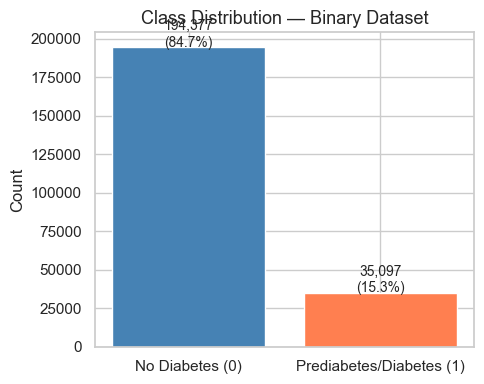


Imbalance ratio: 5.5:1 (no-diabetes : diabetes)


In [9]:
counts = df_clean['Diabetes_binary'].value_counts()
pcts   = df_clean['Diabetes_binary'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(pd.DataFrame({'Count': counts, 'Percent': pcts.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Diabetes (0)', 'Prediabetes/Diabetes (1)'],
       counts.values, color=['steelblue', 'coral'], edgecolor='white')
for i, (c, p) in enumerate(zip(counts.values, pcts.values)):
    ax.text(i, c + 500, f'{c:,}\n({p:.1f}%)', ha='center', fontsize=10)
ax.set_title('Class Distribution — Binary Dataset', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f'\nImbalance ratio: {counts[0]/counts[1]:.1f}:1 (no-diabetes : diabetes)')

> **Why this matters for modeling:** With ~86% of records in class 0, a model that predicts "no diabetes" for every single person achieves 86% accuracy — without learning anything useful. This is the accuracy paradox, and it's exactly why we can't use accuracy as our primary metric here.
>
> For clinical use, **recall (sensitivity)** on the positive class is what actually matters: missing a true diabetic (false negative) is far more costly than a false alarm (false positive). We want a model that catches real cases.
>
> **What to do:**
> - Evaluate with **ROC-AUC, F1, precision-recall curves** — not accuracy
> - Use `class_weight='balanced'` in sklearn models to penalize misclassifying the minority class
> - Consider **SMOTE** to synthetically oversample class 1 before training
> - Set a **classification threshold below 0.5** if maximizing recall is the priority

## 4. Continuous Features — Distributions & Outliers

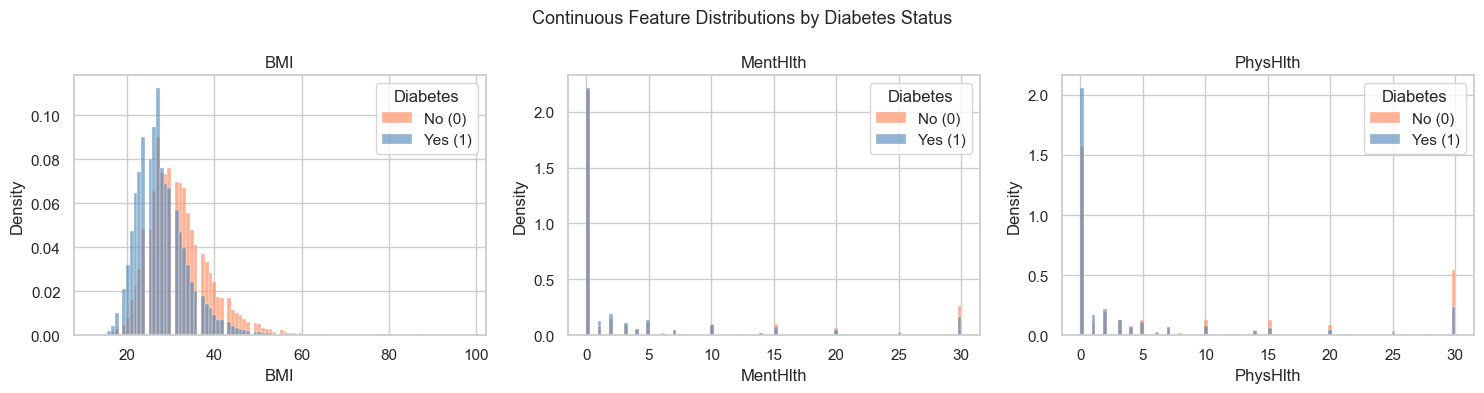

In [10]:
continuous = ['BMI', 'MentHlth', 'PhysHlth']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, continuous):
    sns.histplot(
        data=df_clean, x=col, hue='Diabetes_binary',
        kde=False, stat='density', common_norm=False,
        ax=ax, palette={0: 'steelblue', 1: 'coral'}, alpha=0.6, bins=100
    )
    ax.set_title(col)
    ax.legend(title='Diabetes', labels=['No (0)', 'Yes (1)'])

plt.suptitle('Continuous Feature Distributions by Diabetes Status', fontsize=13)
plt.tight_layout()
plt.show()

> **What we're seeing:** BMI shows a clear rightward shift for diabetic individuals — the distribution peaks at a higher value. This separation is a strong signal and explains why BMI is consistently one of the top predictors across model types.
>
> MentHlth and PhysHlth are heavily zero-inflated — most respondents report zero bad days, which makes these features sparse predictors. The distributions barely separate between classes, meaning they'll contribute less predictive power than BMI. Consider **binarizing** them (0 = none vs. 1 = any bad days) to extract a cleaner signal, or **log-transforming** after adding 1.

In [11]:
# BMI outlier check
print('BMI stats:')
print(df_clean['BMI'].describe())
print(f"\nBMI > 60: {(df_clean['BMI'] > 60).sum()} rows")
print(f"BMI > 80: {(df_clean['BMI'] > 80).sum()} rows")

BMI stats:
count    229474.000000
mean         28.687507
std           6.789204
min          12.000000
25%          24.000000
50%          27.000000
75%          32.000000
max          98.000000
Name: BMI, dtype: float64

BMI > 60: 805 rows
BMI > 80: 279 rows


> **Why BMI outliers matter:** Values above 60 are clinically rare and likely represent measurement error or data entry issues. These extreme values can distort distance-based models (KNN, SVM) and inflate the range for scaling. **Cap BMI at the 99th percentile** before modeling. Tree-based models like XGBoost are naturally robust to outliers since they split on thresholds, but linear models and KNN are not.

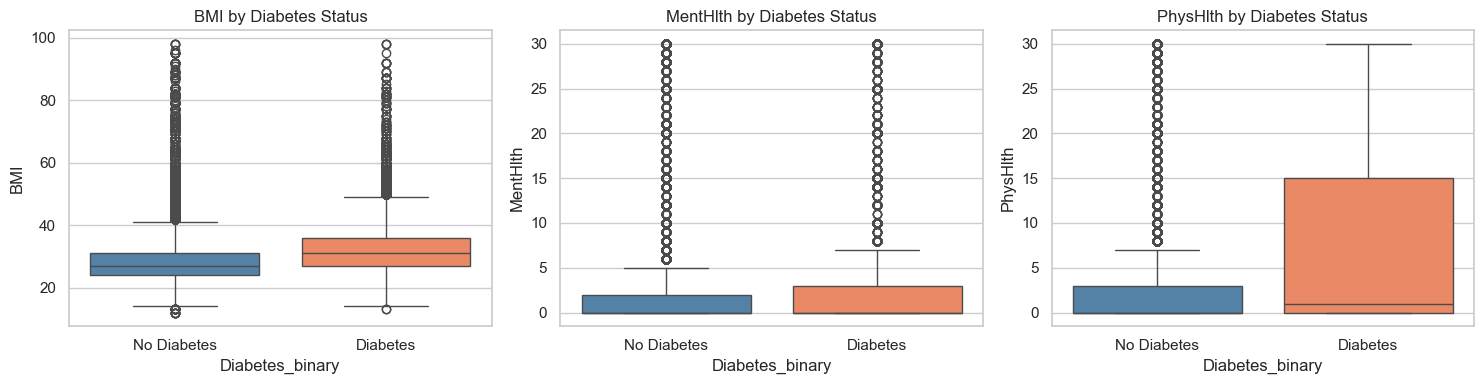

In [12]:
df_clean = df_clean.copy()
df_clean['Diabetes_binary'] = df_clean['Diabetes_binary'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, continuous):
    sns.boxplot(
        data=df_clean, x='Diabetes_binary', y=col,
        hue='Diabetes_binary', palette={0: 'steelblue', 1: 'coral'},
        dodge=False, ax=ax
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Diabetes', 'Diabetes'])
    ax.legend_.remove()
    ax.set_title(f'{col} by Diabetes Status')

plt.tight_layout()
plt.show()

> **Takeaway:** The median BMI for diabetic individuals is noticeably higher, and there are more high-BMI outliers in that group. PhysHlth shows a modest median difference and heavily overlapping IQRs — useful but not decisive on its own. MentHlth shows almost no separation — its signal, if any, comes from the tail.

## 5. Ordinal Features — Diabetes Rate by Level

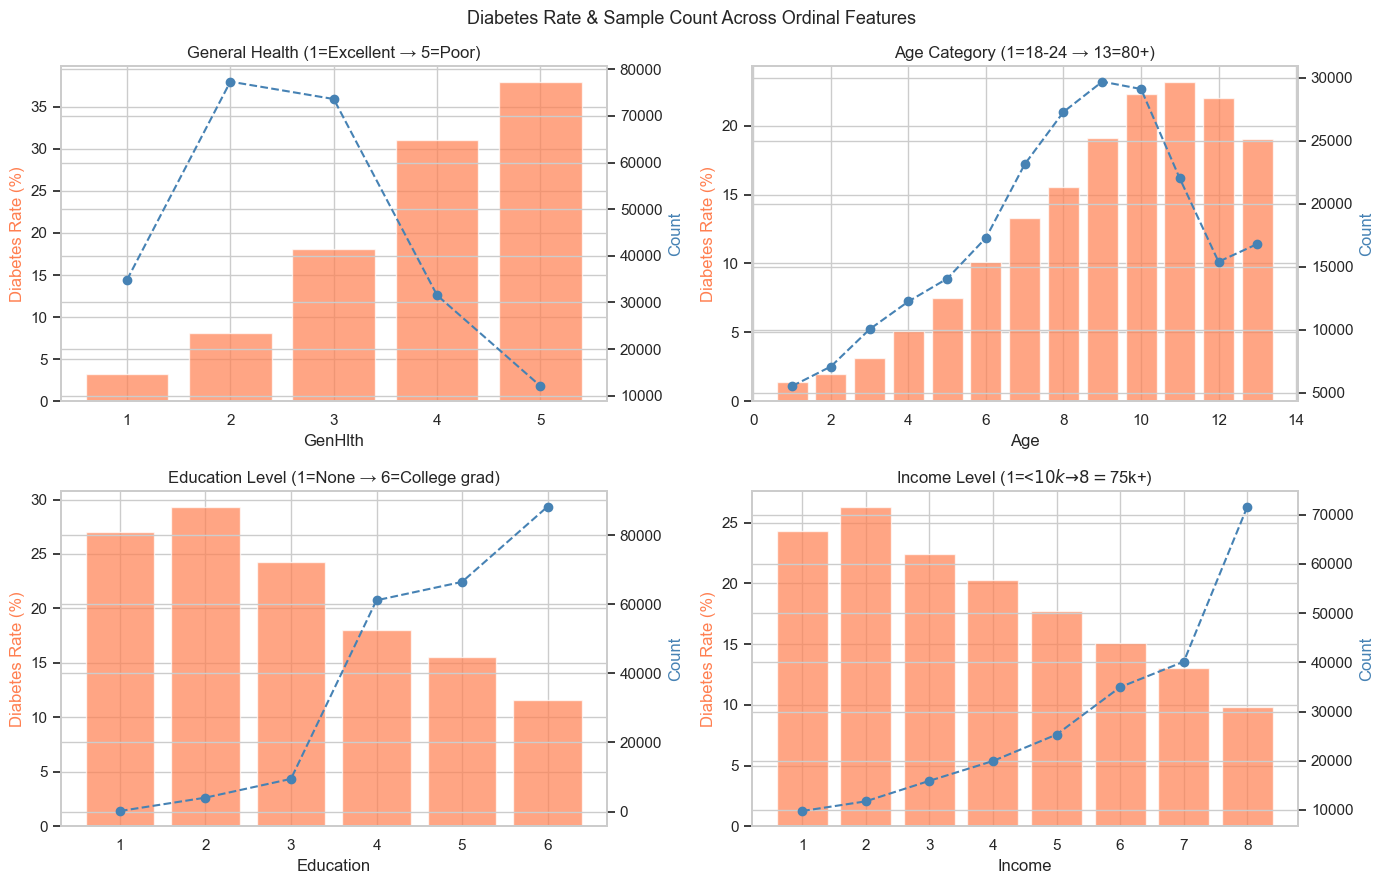

In [13]:
ordinal = {'GenHlth': 'General Health (1=Excellent → 5=Poor)',
           'Age':     'Age Category (1=18-24 → 13=80+)',
           'Education': 'Education Level (1=None → 6=College grad)',
           'Income':  'Income Level (1=<$10k → 8=$75k+)'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, ordinal.items()):
    rate = df_clean.groupby(col)['Diabetes_binary'].mean() * 100
    counts_all = df_clean[col].value_counts().sort_index()
    ax2 = ax.twinx()
    ax.bar(rate.index, rate.values, color='coral', alpha=0.7, label='Diabetes Rate (%)')
    ax2.plot(counts_all.index, counts_all.values, 'o--', color='steelblue', label='N')
    ax.set_xlabel(col)
    ax.set_ylabel('Diabetes Rate (%)', color='coral')
    ax2.set_ylabel('Count', color='steelblue')
    ax.set_title(label)

plt.suptitle('Diabetes Rate & Sample Count Across Ordinal Features', fontsize=13)
plt.tight_layout()
plt.show()

> **What we're seeing and why it matters:**
> 
> The blue dashed line represents the number of observations in each category, plotted on a separate y-axis to show how sample size varies across levels and help interpret how reliable the corresponding diabetes rates are.
>
> **GenHlth** is the strongest ordinal predictor. Diabetes rate climbs from under 5% at level 1 (excellent) to over 35% at level 5 (poor). This near-monotonic relationship means it will be highly ranked by feature importance in every model we try. Domain note: this is partially a chicken-and-egg problem — people with diabetes self-report worse health, so GenHlth is both a risk indicator and a consequence.
>
> **Age** shows a clear positive trend. Risk accelerates in middle age (categories 7–9, roughly 45–64) and stays elevated through the older groups. This aligns with clinical evidence: Type 2 diabetes is strongly age-associated. For modeling, the ordinal encoding is fine as-is — the relationship is already near-linear.
>
> **Income** is inversely related: the lowest-income group has more than 3x the diabetes rate of the highest-income group. This reflects socioeconomic barriers to healthcare access, diet quality, physical activity, and stress — all known diabetes risk factors. Income is likely acting as a **proxy for multiple unmeasured lifestyle variables**.
>
> **Education** follows a similar inverse pattern for the same structural reasons. Note the sample count (blue line): low-education categories have fewer respondents, so those rates are noisier.

## 6. Binary Features — Diabetes Rate Comparison

In [14]:
binary_features = ['HighBP','HighChol','CholCheck','Smoker','Stroke',
                   'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
                   'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']

rates = {}
for col in binary_features:
    r0 = df_clean[df_clean[col]==0]['Diabetes_binary'].mean() * 100
    r1 = df_clean[df_clean[col]==1]['Diabetes_binary'].mean() * 100
    rates[col] = {'Feature=0': r0, 'Feature=1': r1, 'Diff': r1 - r0}

rates_df = pd.DataFrame(rates).T.sort_values('Diff', ascending=False)
print(rates_df.round(2))

                      Feature=0  Feature=1   Diff
HeartDiseaseorAttack      13.24      33.13  19.89
DiffWalk                  11.77      30.77  19.00
HighBP                     6.94      25.33  18.38
Stroke                    14.52      31.78  17.26
HighChol                   9.05      23.18  14.13
CholCheck                  2.59      15.83  13.24
AnyHealthcare             11.48      15.51   4.03
Smoker                    13.77      17.05   3.28
NoDocbcCost               15.06      17.55   2.49
Sex                       14.25      16.63   2.37
Fruits                    16.42      14.58  -1.83
Veggies                   18.25      14.53  -3.72
PhysActivity              21.28      13.11  -8.17
HvyAlcoholConsump         15.90       5.96  -9.93


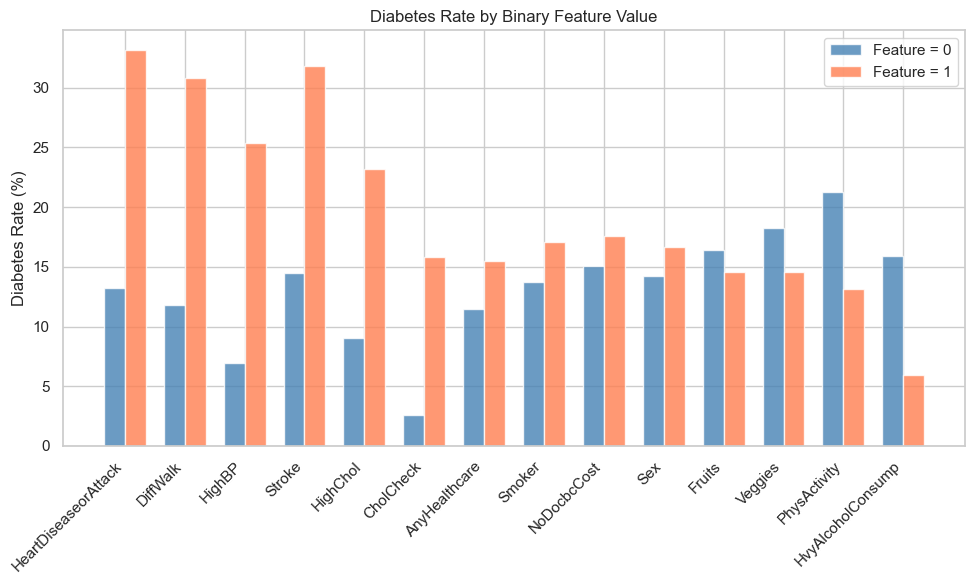

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(rates_df))
width = 0.35
ax.bar(x - width/2, rates_df['Feature=0'], width, label='Feature = 0', color='steelblue', alpha=0.8)
ax.bar(x + width/2, rates_df['Feature=1'], width, label='Feature = 1', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(rates_df.index, rotation=45, ha='right')
ax.set_ylabel('Diabetes Rate (%)')
ax.set_title('Diabetes Rate by Binary Feature Value')
ax.legend()
plt.tight_layout()
plt.show()

>**What we're seeing and why it matters:**
>
> **HeartDiseaseorAttack (+19.89%)**, **DiffWalk (+19.00%)**, **HighBP (+18.38%)**, and **Stroke (+17.26%)** show the strongest increases in diabetes prevalence. These reflect the shared cardiovascular and metabolic pathways underlying both diabetes and heart disease, making them some of the most important predictive features.  
>
> **HighChol (+14.13%)** and **CholCheck (+13.24%)** also show strong associations. High cholesterol is a known metabolic risk factor, while CholCheck likely reflects healthcare engagement, which is indirectly linked to higher diagnosed prevalence.  
>
> **PhysActivity (-8.17%)** shows a clear negative difference, indicating physically active individuals are less likely to have diabetes, consistent with its protective metabolic effect.  
>
> **HvyAlcoholConsump (-9.93%)** also shows a strong negative association, which is likely due to behavioral or sampling bias rather than a true protective effect.  
>
> **Fruits (-1.83%)** and **Veggies (-3.72%)** show small negative differences, suggesting weak but consistent protective dietary patterns.  
>
> **AnyHealthcare, Smoker, NoDocbcCost, and Sex** show small differences, suggesting these are weaker predictors and may act more as indirect socioeconomic or access-related indicators rather than direct causal factors.

## 7. Correlation Analysis

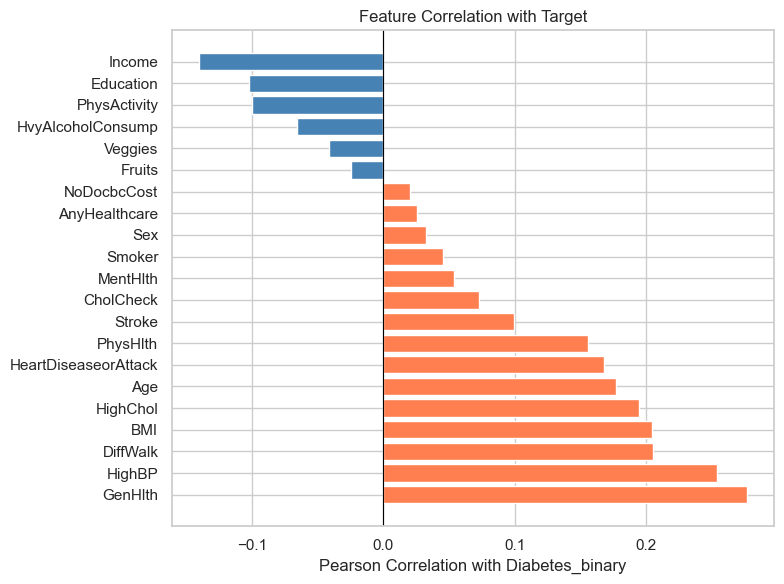

GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


In [16]:
corr_target = df_clean.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['coral' if c > 0 else 'steelblue' for c in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Diabetes_binary')
ax.set_title('Feature Correlation with Target')
plt.tight_layout()
plt.show()

print(corr_target)

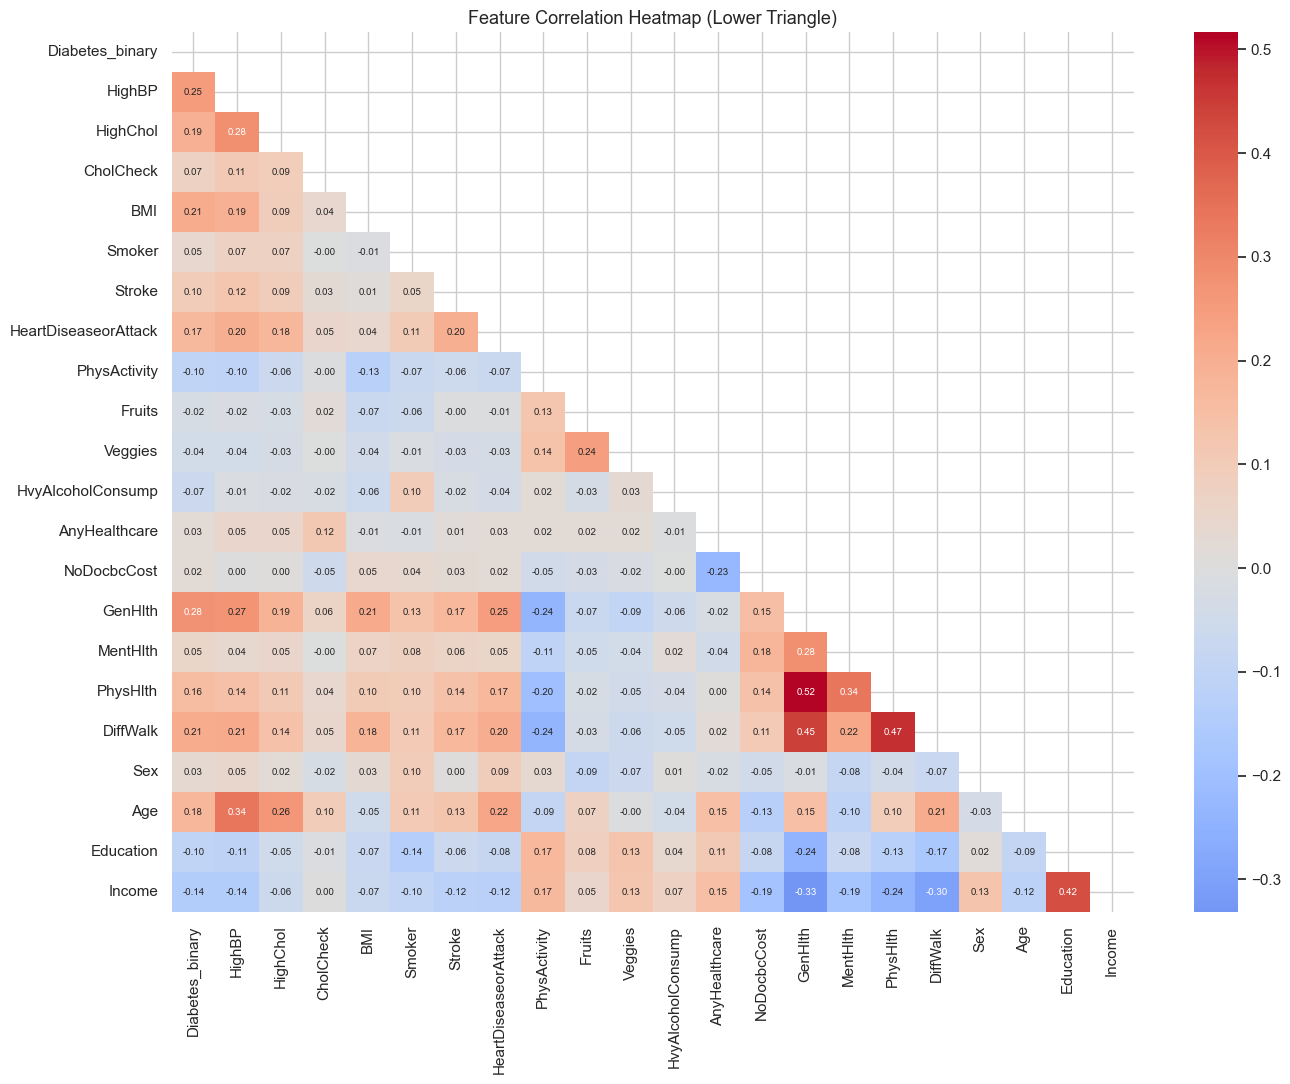

In [17]:
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(df_clean.corr(), dtype=bool))
sns.heatmap(df_clean.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.show()

> **What we're seeing and why it matters:**
>
> **Top positive correlates with the target:** GenHlth, HighBP, BMI, DiffWalk, HighChol. These are your most important features going into modeling — expect them to dominate feature importance rankings across model types.
>
> **Top negative correlates:** Income, Education, PhysActivity. These are protective/socioeconomic factors. Their negative correlation is real and meaningful, not an artifact.
>
> **Multicollinearity risk:** PhysHlth and GenHlth are correlated at 0.52 — the highest inter-feature correlation in the dataset. DiffWalk and PhysHlth also correlate at 0.47. For **Logistic Regression**, these pairs inflate coefficient variance and make individual coefficient interpretation unreliable. Consider dropping one from each pair or using regularization (L2). **For tree-based models (XGBoost, Random Forest), this is not a problem** — trees automatically handle correlated features by splitting on whichever is more informative at each node.
>
> **Important caveat:** Pearson correlation only captures linear relationships. A feature with low correlation here might still be a strong predictor via nonlinear interactions — tree models will find these automatically.

## 8. Key Interaction Patterns

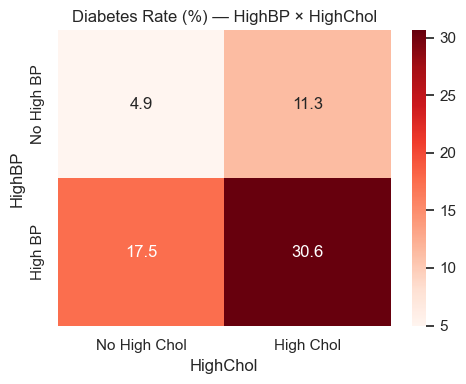

In [18]:
# Heatmap: HighBP × HighChol → diabetes rate
pivot = df_clean.groupby(['HighBP', 'HighChol'])['Diabetes_binary'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', ax=ax,
            xticklabels=['No High Chol', 'High Chol'],
            yticklabels=['No High BP', 'High BP'])
ax.set_title('Diabetes Rate (%) — HighBP × HighChol')
plt.tight_layout()
plt.show()

> **Why this interaction matters:** Having both high BP and high cholesterol isn't just additive — the combination shows a substantially higher diabetes rate than either risk factor alone. This is the metabolic syndrome pattern: these conditions cluster together and compound cardiovascular and metabolic risk. For models, this suggests that an **interaction term** between HighBP and HighChol could improve a logistic regression model. Tree models will discover this interaction automatically.

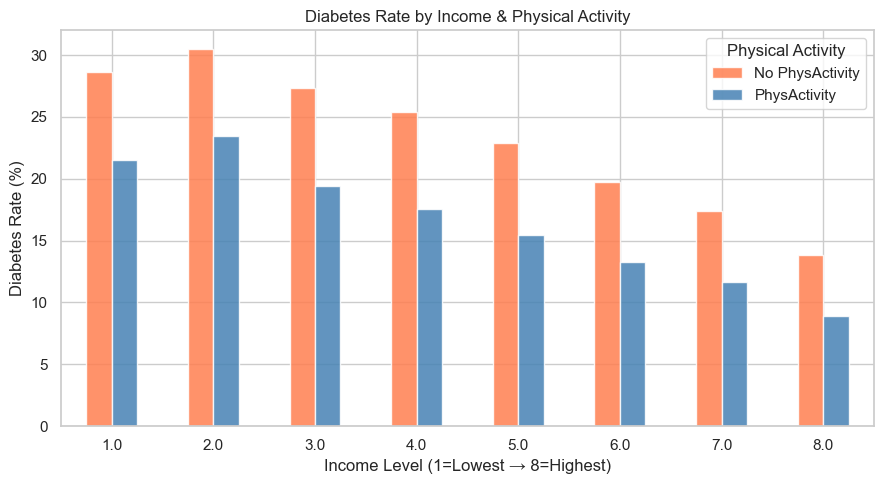

In [19]:
# Diabetes rate by income & physical activity
pivot2 = df_clean.groupby(['Income', 'PhysActivity'])['Diabetes_binary'].mean().unstack() * 100
pivot2.columns = ['No PhysActivity', 'PhysActivity']

pivot2.plot(kind='bar', figsize=(9, 5), color=['coral','steelblue'], alpha=0.85, edgecolor='white')
plt.xlabel('Income Level (1=Lowest → 8=Highest)')
plt.ylabel('Diabetes Rate (%)')
plt.title('Diabetes Rate by Income & Physical Activity')
plt.legend(title='Physical Activity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> **What we're seeing:** Physical activity is protective at every income level — the steelblue bars (active) are consistently below the coral bars (inactive). However, the income gradient persists regardless of activity level: even active low-income individuals have higher diabetes rates than inactive high-income individuals. This tells us that **income captures something beyond just whether someone exercises** — likely diet quality, healthcare access, chronic stress, and neighborhood environment. Both variables contribute independently and together.

## 9. Preprocessing & Modeling Checklist

| Issue | Finding | Action |
|---|---|---|
| **Class Imbalance** | ~86% / ~14% split | Use `class_weight='balanced'`, SMOTE, evaluate with F1/ROC-AUC |
| **Duplicate rows** | ~24k duplicates | Drop **before** train/test split to prevent leakage |
| **BMI outliers** | Values >60 exist | Cap at 99th percentile for LR/SVM/KNN; trees are robust |
| **Skewed MentHlth/PhysHlth** | Zero-inflated, weak signal | Consider binarizing (any bad days vs. none) or log(x+1) transform |
| **Multicollinearity** | PhysHlth–GenHlth (0.54), DiffWalk–PhysHlth (0.43) | Regularize LR; not an issue for tree models |
| **Feature scaling** | BMI, MentHlth, PhysHlth are continuous | Scale for LR, SVM, KNN — unnecessary for trees |
| **No missing values** | Dataset is clean | No imputation needed |

In [20]:
print('Feature means by class:')
df_clean.groupby('Diabetes_binary')[continuous + list(ordinal.keys())].mean().round(2)

Feature means by class:


,BMI,MentHlth,PhysHlth,GenHlth,Age,Education,Income
Diabetes_binary,,,,,,,
0,28.10,3.33,4.08,2.48,7.85,5.02,6.01
1,31.96,4.49,8.01,3.30,9.38,4.74,5.20
